нсталяція scipy та імпорт бібліотек

In [1]:
!pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, lfilter


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Базові налаштування часу
t = np.linspace(0, 1, 1000)

# Глобальна змінна для фіксації шуму, щоб він не генерувався наново при зміні гармоніки
cached_noise = None
current_noise_mean = 0.0
current_noise_cov = 0.1

def get_noise(mean, covariance):
    global cached_noise, current_noise_mean, current_noise_cov
    # Якщо параметри шуму змінилися або шуму ще немає — генеруємо заново
    if cached_noise is None or current_noise_mean != mean or current_noise_cov != covariance:
        cached_noise = np.random.normal(mean, np.sqrt(covariance), len(t))
        current_noise_mean = mean
        current_noise_cov = covariance
    return cached_noise

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
    # Чиста гармоніка
    y_pure = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    
    if show_noise:
        noise = get_noise(noise_mean, noise_covariance)
        y_noisy = y_pure + noise
        return y_pure, y_noisy
    else:
        return y_pure, y_pure.copy()

# Фільтр низьких частот Баттерворта
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = lfilter(b, a, data)
    return y

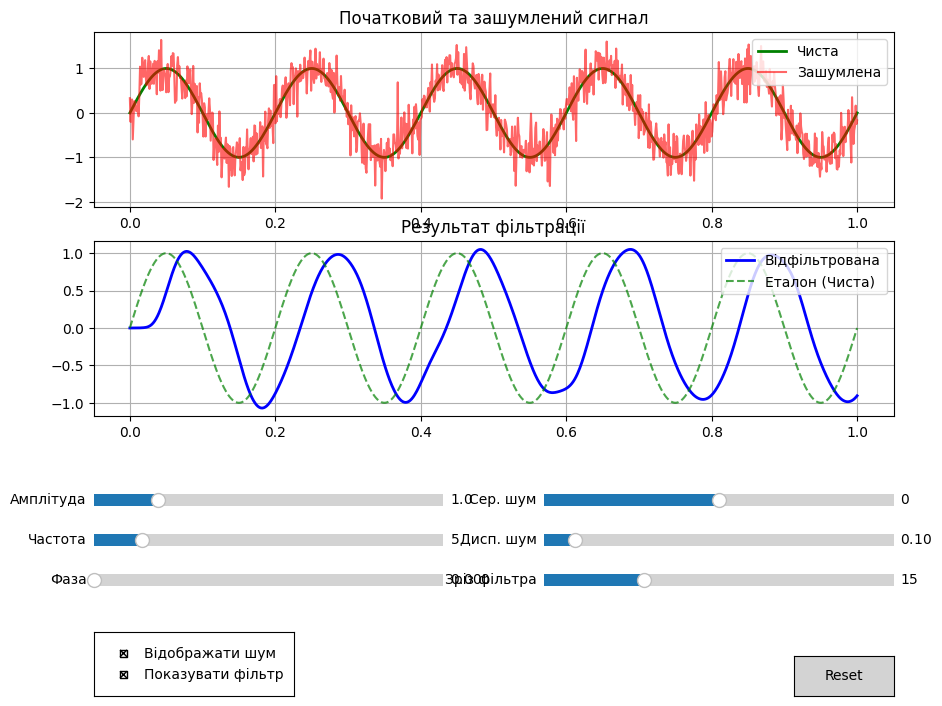

In [3]:
# Початкові параметри
init_amp = 1.0
init_freq = 5.0
init_phase = 0.0
init_mean = 0.0
init_cov = 0.1
init_cutoff = 15.0

# Налаштування вікна та графіків
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(left=0.1, bottom=0.4)

# Генеруємо початкові сигнали
y_pure, y_noisy = harmonic_with_noise(init_amp, init_freq, init_phase, init_mean, init_cov, True)
y_filtered = butter_lowpass_filter(y_noisy, init_cutoff, fs=1000)

# Малюємо графіки
line_pure, = ax1.plot(t, y_pure, label='Чиста', color='green', lw=2)
line_noisy, = ax1.plot(t, y_noisy, label='Зашумлена', color='red', alpha=0.6)
ax1.set_title("Початковий та зашумлений сигнал")
ax1.legend(loc='upper right')
ax1.grid(True)

line_filtered, = ax2.plot(t, y_filtered, label='Відфільтрована', color='blue', lw=2)
line_pure_target, = ax2.plot(t, y_pure, label='Еталон (Чиста)', color='green', linestyle='--', alpha=0.7)
ax2.set_title("Результат фільтрації")
ax2.legend(loc='upper right')
ax2.grid(True)

# Слайдери для гармоніки
ax_amp = plt.axes([0.1, 0.28, 0.35, 0.03])
ax_freq = plt.axes([0.1, 0.23, 0.35, 0.03])
ax_phase = plt.axes([0.1, 0.18, 0.35, 0.03])

s_amp = Slider(ax_amp, 'Амплітуда', 0.1, 5.0, valinit=init_amp)
s_freq = Slider(ax_freq, 'Частота', 1.0, 30.0, valinit=init_freq)
s_phase = Slider(ax_phase, 'Фаза', 0.0, 2*np.pi, valinit=init_phase)

# Слайдери для шуму та фільтра
ax_mean = plt.axes([0.55, 0.28, 0.35, 0.03])
ax_cov = plt.axes([0.55, 0.23, 0.35, 0.03])
ax_cutoff = plt.axes([0.55, 0.18, 0.35, 0.03])

s_mean = Slider(ax_mean, 'Сер. шум', -1.0, 1.0, valinit=init_mean)
s_cov = Slider(ax_cov, 'Дисп. шум', 0.01, 1.0, valinit=init_cov)
s_cutoff = Slider(ax_cutoff, 'Зріз фільтра', 1.0, 50.0, valinit=init_cutoff)

# Чекбокс для відображення шуму та фільтра
ax_check = plt.axes([0.1, 0.05, 0.2, 0.08])
chk_buttons = CheckButtons(ax_check, ['Відображати шум', 'Показувати фільтр'], [True, True])

# Кнопка Reset
ax_reset = plt.axes([0.8, 0.05, 0.1, 0.05])
btn_reset = Button(ax_reset, 'Reset', color='lightgray', hovercolor='0.9')

# Функція оновлення графіків
def update(val):
    show_noise = chk_buttons.get_status()[0]
    show_filter = chk_buttons.get_status()[1]
    
    # Отримуємо значення зі слайдерів
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    mean = s_mean.val
    cov = s_cov.val
    cutoff = s_cutoff.val
    
    y_p, y_n = harmonic_with_noise(amp, freq, phase, mean, cov, show_noise)
    
    # Оновлюємо лінії першого графіка
    line_pure.set_ydata(y_p)
    if show_noise:
        line_noisy.set_ydata(y_n)
        line_noisy.set_visible(True)
    else:
        line_noisy.set_visible(False)
        
    # Оновлюємо лінії другого графіка (Фільтрація)
    line_pure_target.set_ydata(y_p)
    if show_filter and show_noise:
        y_f = butter_lowpass_filter(y_n, cutoff, fs=1000)
        line_filtered.set_ydata(y_f)
        line_filtered.set_visible(True)
    elif show_filter and not show_noise:
        line_filtered.set_ydata(y_p)
        line_filtered.set_visible(True)
    else:
        line_filtered.set_visible(False)
        
    fig.canvas.draw_idle()

# Зв'язуємо події
s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_mean.on_changed(update)
s_cov.on_changed(update)
s_cutoff.on_changed(update)
chk_buttons.on_clicked(update)

# Функція скидання
def reset(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_mean.reset()
    s_cov.reset()
    s_cutoff.reset()
btn_reset.on_clicked(reset)

plt.show()